In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [27]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [28]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [29]:
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [30]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

In [31]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])


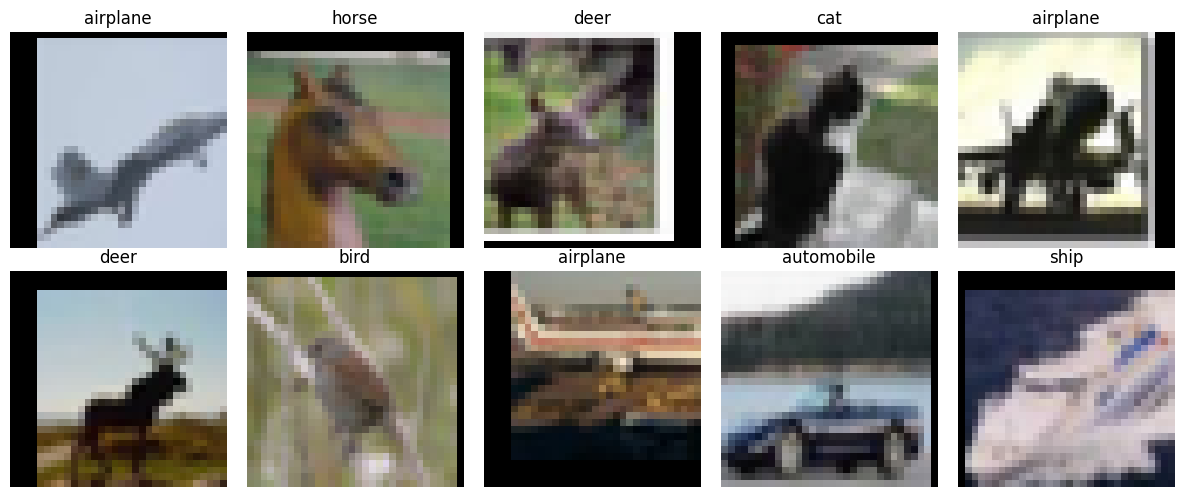

In [32]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0).numpy()

    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
class CNN(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(128, 10)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [37]:
model = CNN().to(device)
print(model)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


In [38]:

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 94986
Trainable parameters: 94986
Total parameters: 94986
Trainable parameters: 94986


In [39]:
criterion = nn.CrossEntropyLoss()

In [40]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [41]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [42]:
def evaluate(model, loader, criterion, device):
    
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [43]:
num_epochs = 20

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Loss: {test_loss:.4f} "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch [1/20] Train Loss: 1.5353 Train Acc: 44.65% Test Loss: 1.4004 Test Acc: 48.55%
Epoch [2/20] Train Loss: 1.2366 Train Acc: 55.84% Test Loss: 1.5614 Test Acc: 47.73%
Epoch [3/20] Train Loss: 1.1258 Train Acc: 59.97% Test Loss: 1.3202 Test Acc: 53.93%
Epoch [4/20] Train Loss: 1.0558 Train Acc: 62.24% Test Loss: 1.1186 Test Acc: 60.33%
Epoch [5/20] Train Loss: 0.9974 Train Acc: 64.85% Test Loss: 1.1407 Test Acc: 60.83%
Epoch [6/20] Train Loss: 0.9596 Train Acc: 66.27% Test Loss: 1.0593 Test Acc: 62.13%
Epoch [7/20] Train Loss: 0.9165 Train Acc: 67.80% Test Loss: 1.0185 Test Acc: 64.39%
Epoch [8/20] Train Loss: 0.8884 Train Acc: 68.96% Test Loss: 0.9581 Test Acc: 65.74%
Epoch [9/20] Train Loss: 0.8629 Train Acc: 69.70% Test Loss: 1.0326 Test Acc: 65.29%
Epoch [10/20] Train Loss: 0.8348 Train Acc: 70.97% Test Loss: 0.9171 Test Acc: 67.81%
Epoch [11/20] Train Loss: 0.8129 Train Acc: 71.72% Test Loss: 0.8768 Test Acc: 69.44%
Epoch [12/20] Train Loss: 0.7874 Train Acc: 72.78% Test Loss: 0

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    test_losses,
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")

plt.legend()
plt.grid()
plt.show()